In [ ]:
import os
import zipfile
import cv2
import numpy as np


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/ECG_images_classfication.zip"
extract_path = "/mnt/data/ecg_raw"

# Check if the zip file exists before attempting to extract
if not os.path.exists(zip_path):
    print(f"Error: The file '{zip_path}' was not found.")
    print("Please ensure the zip file is uploaded to your Google Drive and the path is correct.")
    print("If you intend to upload a file from your local machine, use `from google.colab import files` and then `uploaded = files.upload()` to upload it.")
else:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Extracted to:", extract_path)

Error: The file '/content/drive/MyDrive/ECG_images_classfication.zip' was not found.
Please ensure the zip file is uploaded to your Google Drive and the path is correct.
If you intend to upload a file from your local machine, use `from google.colab import files` and then `uploaded = files.upload()` to upload it.


In [ ]:
def remove_header_footer_only(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    h, w, _ = img.shape

    # ==========================
    # REMOVE ONLY TOP & BOTTOM
    # ==========================
    top_cut = int(0.17 * h)      # removes ECG REPORT section
    bottom_cut = int(0.94 * h)   # removes footer text

    trimmed = img[top_cut:bottom_cut, :]  # keep full width

    return trimmed


In [ ]:
input_dir = "/mnt/data/ecg_raw"
output_dir = "/mnt/data/ecg_trimmed"

os.makedirs(output_dir, exist_ok=True)

for cls in os.listdir(input_dir):
    cls_input = os.path.join(input_dir, cls)
    cls_output = os.path.join(output_dir, cls)

    if not os.path.isdir(cls_input):
        continue

    os.makedirs(cls_output, exist_ok=True)

    for img_name in os.listdir(cls_input):
        img_path = os.path.join(cls_input, img_name)

        trimmed_img = remove_header_footer_only(img_path)

        if trimmed_img is None:
            continue

        cv2.imwrite(
            os.path.join(cls_output, img_name),
            trimmed_img
        )

    print(f"Processed: {cls}")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/ecg_raw'

In [ ]:
import matplotlib.pyplot as plt

sample_class = os.listdir(output_dir)[0]
sample_img = os.listdir(os.path.join(output_dir, sample_class))[0]

img = cv2.imread(os.path.join(output_dir, sample_class, sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.imshow(img)
plt.axis("off")
plt.title("Header & Footer Removed – ECG Box Preserved")


In [ ]:
import os

processed_path = "/mnt/data/ecg_trimmed"   # 🔴 change ONLY if your folder name is different

total = 0
for root, dirs, files in os.walk(processed_path):
    print(root, "->", len(files), "files")
    total += len(files)

print("Total images:", total)


In [ ]:
import zipfile
import os

zip_path = "/content/ecg_trimmed_dataset.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(processed_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, processed_path)
            zipf.write(file_path, arcname)

print("ZIP created at:", zip_path)


In [2]:
pip install torch torchvision scikit-learn matplotlib numpy pillow tqdm

In [3]:
import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 2
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # ECG images often grayscale
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [6]:
import os
import shutil
import random

# ================= CONFIG =================
SOURCE_DIR = "/content/drive/MyDrive/ECG_IMAGES_1"     # your original dataset
DEST_DIR = "dataset"          # new dataset directory

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
random.seed(SEED)

# =========================================

classes = os.listdir(SOURCE_DIR)

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "test", cls, img)
        )

print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [7]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from collections import Counter

def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        counts[cls] = len(os.listdir(os.path.join(path, cls)))
    return counts

print("Train:", count_images("/content/dataset/train"))
print("Val:", count_images("/content/dataset/val"))
print("Test:", count_images("/content/dataset/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382}
Val: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81}
Test: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83}


handling class imbalance


In [11]:
class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = class_weights[train_dataset.targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
import os

def count_images_per_class(dataset_path):
    class_counts = {}
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                img for img in os.listdir(cls_path)
                if img.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return class_counts

print("Train set:", count_images_per_class("dataset/train"))
print("Validation set:", count_images_per_class("dataset/val"))
print("Test set:", count_images_per_class("dataset/test"))

Train set: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382}
Validation set: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81}
Test set: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83}


In [14]:
import numpy as np
from collections import Counter

targets = train_dataset.targets  # class labels
class_counts = Counter(targets)

print("Original class distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} images")

# Effective sampling per epoch
sampled_indices = list(train_loader.sampler)
sampled_targets = [targets[i] for i in sampled_indices]
sampled_counts = Counter(sampled_targets)

print("\nEffective distribution per epoch (after imbalance handling):")
for cls, count in sampled_counts.items():
    print(f"Class {cls}: {count} samples")

Original class distribution:
Class 0: 382 images
Class 1: 601 images

Effective distribution per epoch (after imbalance handling):
Class 1: 490 samples
Class 0: 493 samples


In [15]:
class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attn = torch.softmax(torch.matmul(Q, K.transpose(-2, -1)) * self.scale, dim=-1)
        out = torch.matmul(attn, V)
        return out

In [16]:
class ResNetXAttn(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()

        self.attn = CrossAttention(dim=512)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)       # (B, 512)
        features = features.unsqueeze(1)  # (B, 1, 512)

        attn_out = self.attn(features)
        attn_out = attn_out.squeeze(1)

        return self.classifier(attn_out)

In [17]:
model = ResNetXAttn(NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


In [18]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0

    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [19]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return all_labels, all_preds

In [20]:
for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss:.4f}")

100%|██████████| 62/62 [00:51<00:00,  1.21it/s]


Epoch [1/20], Loss: 0.3855


100%|██████████| 62/62 [00:49<00:00,  1.25it/s]


Epoch [2/20], Loss: 0.2744


100%|██████████| 62/62 [00:48<00:00,  1.28it/s]


...

Epoch [18/20], Loss: 0.0750


100%|██████████| 62/62 [00:49<00:00,  1.25it/s]


Epoch [19/20], Loss: 0.0509


100%|██████████| 62/62 [00:47<00:00,  1.30it/s]

Epoch [20/20], Loss: 0.0316


In [21]:
labels, preds = evaluate(model, val_loader)
print("\nClassification Report:")
print(classification_report(labels, preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82        81
           1       0.86      0.93      0.89       128

    accuracy                           0.87       209
   macro avg       0.87      0.85      0.86       209
weighted avg       0.87      0.87      0.86       209



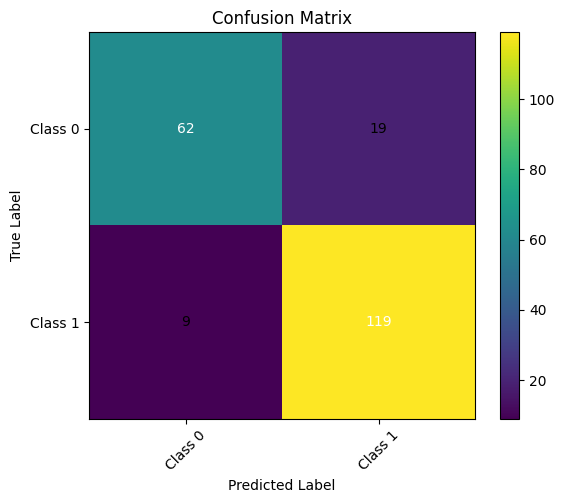

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(labels, preds)

# Class names (change if needed)
class_names = ["Class 0", "Class 1"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add numbers inside cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

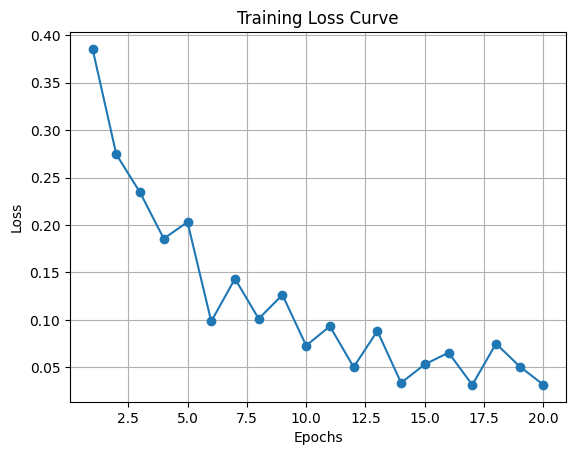

In [23]:
import matplotlib.pyplot as plt

# Updated training losses (20 epochs)
train_losses = [
    0.3855, 0.2744, 0.2343, 0.1856, 0.2031,
    0.0984, 0.1434, 0.1012, 0.1264, 0.0729,
    0.0933, 0.0503, 0.0883, 0.0337, 0.0532,
    0.0655, 0.0315, 0.0750, 0.0509, 0.0316
]

# Epochs
epochs = list(range(1, len(train_losses) + 1))

# Plot
plt.figure()

plt.plot(epochs, train_losses, marker='o')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid()

plt.show()